# Arch 3 panel vs hapFIRE — proper allele-aware comparison (SEEDMIX_S1 Chr1)

**Updated 2026-05-20.** Arch 3 = HPRC-style symbolic-ID decomposition (`prepare-vcf-MC` + `convert-to-biallelic.py`) replacing the `bcftools norm -m -any` scatter bug. Uses `cn_var_231_arch3_chr1` with called mask for AC/AN projection.

Comparing to:
- **hapFIRE**: xwu's 2023 production HARP+CVXPY on the 231-panel `greneNet_final_v1.1`.
- **recipe truth**: uniform-h projection through cn_var — panel-intrinsic AF (the floor cactus_em can reach when h ≈ uniform).
- **cactus_em arch3**: h_v3 vector (from prior v3qc_v3 SEEDMIX run) projected through the NEW arch3 cn_var. Single-config (no α sweep yet).

In [39]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import load_npz

ROOT = Path('/global/scratch/users/tbellg/kmate')
ARCH = ROOT / 'arch3' / 'chr1'
HF_DIR = Path('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix')
HF_VCF = Path('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/vcf/greneNet_final_v1.1.recode.vcf')

meta = np.load(ARCH / 'cn_var_231_arch3_chr1.meta.npz', allow_pickle=True)
rec_chrom = np.asarray(meta['chrom']).astype(str)
rec_pos   = np.asarray(meta['pos']).astype(np.int64)
rec_rlen  = np.asarray(meta['ref_len']).astype(np.int32)
rec_alen  = np.asarray(meta['alt_len']).astype(np.int32)
# Don't .astype(str) on ref/alt — some SV alleles are 100K+ bp so a fixed-width
# numpy string array would need 2.2 TB. Keep as object arrays.
rec_ref   = np.asarray(meta['ref'], dtype=object) if 'ref' in meta.files else None
rec_alt   = np.asarray(meta['alt'], dtype=object) if 'alt' in meta.files else None

print(f'meta keys: {meta.files}')
if rec_ref is not None:
    print(f'has REF/ALT base strings: yes')
else:
    print(f'has REF/ALT base strings: NO — falling back to position-only alignment')

chr1_snp_mask = (rec_chrom == 'Chr1') & (rec_rlen == 1) & (rec_alen == 1)
chr1_snp_idx = np.where(chr1_snp_mask)[0]
chr1_snp_pos = rec_pos[chr1_snp_idx]
print(f'Chr1 SNP records in arch3 cn_var: {len(chr1_snp_idx):,}')

cn_var = load_npz(ARCH / 'cn_var_231_arch3_chr1.cn_var.npz')
F = cn_var.shape[0]

called_path = ARCH / 'cn_var_231_arch3_chr1.cn_var_called.npz'
if called_path.exists():
    cn_var_called = load_npz(called_path)
    print(f'cn_var_called loaded: shape={cn_var_called.shape}, nnz={cn_var_called.nnz:,}')
else:
    cn_var_called = None
    print(f'WARNING: cn_var_called not found at {called_path} — fixed recipe unavailable')

meta keys: ['founders', 'chrom', 'pos', 'ref', 'alt', 'ref_len', 'alt_len']
has REF/ALT base strings: yes
Chr1 SNP records in arch3 cn_var: 1,896,034
cn_var_called loaded: shape=(231, 2617370), nnz=520,884,339


In [40]:
# --- Build recipe truths ---
TRUTH_H = np.full(F, 1.0/F, dtype=np.float32)
cv_chr1 = cn_var[:, chr1_snp_idx].toarray().astype(np.float32)
recipe_legacy = TRUTH_H @ cv_chr1

if cn_var_called is not None:
    cvc_chr1 = cn_var_called[:, chr1_snp_idx].toarray().astype(np.float32)
    called_weight = TRUTH_H @ cvc_chr1
    safe = np.maximum(called_weight, 1e-12)
    recipe_fixed = (recipe_legacy / safe).astype(np.float32)
    # Diagnostic: how often does the fix differ from legacy?
    diff = recipe_fixed - recipe_legacy
    print(f'recipe_fixed - recipe_legacy: mean={diff.mean():+.4f}, max={diff.max():.4f}, min={diff.min():.4f}')
    print(f'records where |fix-legacy|>0.1: {(np.abs(diff)>0.1).sum():,} ({(np.abs(diff)>0.1).mean()*100:.2f}%)')
    print(f'  fix - legacy positive: {(diff>0.01).sum():,}, negative: {(diff<-0.01).sum():,}')
else:
    recipe_fixed = None

print(f'\nrecipe_legacy: min={recipe_legacy.min():.4f}, max={recipe_legacy.max():.4f}, mean={recipe_legacy.mean():.4f}')
if recipe_fixed is not None:
    print(f'recipe_fixed:  min={recipe_fixed.min():.4f}, max={recipe_fixed.max():.4f}, mean={recipe_fixed.mean():.4f}')

recipe_fixed - recipe_legacy: mean=+0.0131, max=0.9091, min=0.0000
records where |fix-legacy|>0.1: 56,946 (3.00%)
  fix - legacy positive: 356,008, negative: 0

recipe_legacy: min=0.0000, max=1.0000, mean=0.0745
recipe_fixed:  min=0.0000, max=1.0000, mean=0.0875


In [41]:
# --- Load arch3 cactus_em config(s). Currently single config; add tiers when alpha-sweep is run on arch3. ---
CONFIGS = {
    'arch3 (chr1 ID-decomp)': [ARCH / 'SEEDMIX_S1_arch3_chr1.tsv'],
}

def load_cem_chr1_snp_af(tsv_path):
    df = pd.read_csv(tsv_path, sep='\t')
    return df['alt_freq'].to_numpy()[chr1_snp_idx]

cem_af = {}
config_source = {}
for name, candidates in CONFIGS.items():
    found = None
    for c in candidates:
        if c.exists():
            found = c
            break
    if found is None:
        print(f'  ✗ MISSING: {name}')
        continue
    cem_af[name] = load_cem_chr1_snp_af(found)
    config_source[name] = found.parent.name
    print(f'  ✓ {name}: n={len(cem_af[name]):,}  (from {found})')

# --- hapFIRE: xwu's per-SNP AF for SEEDMIX_S1 + REF/ALT from greneNet_v1.1 for 4-tuple join ---
hf_raw = pd.read_csv(HF_DIR / 's1_snp_frequency.txt', sep='\t',
                     header=None, names=['chrom','pos','af'])
hf_raw = hf_raw[hf_raw['chrom'].astype(str) == '1']
ra = pd.read_csv(HF_VCF, sep='\t', comment='#', header=None,
                 usecols=[0,1,3,4], names=['chrom','pos','ref','alt'])
ra = ra[ra['chrom'].astype(str) == '1']
hf_full = hf_raw.merge(ra, on=['chrom','pos'], how='left').dropna(subset=['ref','alt'])
print(f'\nhapFIRE chr1 SNPs w/ REF/ALT: {len(hf_full):,}')

# Build (pos,ref,alt) → AF lookup from hapFIRE
hf_key = dict(zip(
    zip(hf_full['pos'].astype(np.int64), hf_full['ref'].astype(str), hf_full['alt'].astype(str)),
    hf_full['af'].astype(np.float32)
))

# Align hapFIRE to our SNP records by 4-tuple (chrom_num=1, pos, ref, alt).
# Where arch3 splits a multi-allelic snarl into multiple biallelic rows, the 4-tuple join
# only matches the ALT that hapFIRE has (the others stay NaN).
chr1_snp_ref = [str(rec_ref[i]) for i in chr1_snp_idx] if rec_ref is not None else None
chr1_snp_alt = [str(rec_alt[i]) for i in chr1_snp_idx] if rec_alt is not None else None
hf_af = np.array(
    [hf_key.get((int(chr1_snp_pos[i]), chr1_snp_ref[i], chr1_snp_alt[i]), np.nan)
     for i in range(len(chr1_snp_idx))],
    dtype=np.float32
)
print(f'hapFIRE aligned by 4-tuple: n_finite={np.isfinite(hf_af).sum():,} / {len(hf_af):,}')

# --- single_alt_mask: positions with exactly ONE ALT row in our panel ---
# (Per-position dedup; arch3 has many multi-allelic positions due to symbolic-ID decomposition.)
from collections import Counter
pos_counts = Counter(chr1_snp_pos.tolist())
single_alt_mask = np.array([pos_counts[p] == 1 for p in chr1_snp_pos])
print(f'Single-ALT positions (clean for hapFIRE join): {single_alt_mask.sum():,} / {len(chr1_snp_pos):,}')
# Note: with 4-tuple alignment above, single_alt_mask is less critical than in v3qc_v3.
# Kept for parity with the original notebook structure.

  ✓ arch3 (chr1 ID-decomp): n=1,896,034  (from /global/scratch/users/tbellg/kmate/panel/arch3/chr1/SEEDMIX_S1_arch3_chr1.tsv)

hapFIRE chr1 SNPs w/ REF/ALT: 827,765
hapFIRE aligned by 4-tuple: n_finite=660,655 / 1,896,034
Single-ALT positions (clean for hapFIRE join): 1,749,086 / 1,896,034


hapFIRE aligned by 4-tuple: n_finite=660,655 / 1,896,034


Single-ALT positions (clean for hapFIRE join): 1,749,086 / 1,896,034


In [42]:
def metrics(x, y, mask=None):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if mask is not None:
        finite = finite & mask
    if finite.sum() < 5:
        return None
    xv = x[finite]; yv = y[finite]
    return dict(
        n=int(finite.sum()),
        r2=float(np.corrcoef(xv, yv)[0,1]**2),
        mae=float(np.mean(np.abs(yv - xv))),
        rmse=float(np.sqrt(np.mean((yv - xv)**2))),
        slope=float(np.polyfit(xv, yv, 1)[0]),
        signed=float(np.mean(yv - xv)),
        out=float(np.mean(np.abs(yv - xv) > 0.1)),
    )

def hexbin(ax, x, y, xlabel, ylabel, title, mask=None):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if mask is not None:
        finite = finite & mask
    if finite.sum() < 5:
        ax.text(0.5, 0.5, 'no overlap', ha='center', va='center')
        return
    hb = ax.hexbin(x[finite], y[finite], gridsize=80, cmap='viridis',
                   norm=LogNorm(), mincnt=1)
    ax.plot([0,1],[0,1],'r--', lw=0.7, alpha=0.7)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    m = metrics(x, y, mask)
    ax.set_title(
        f'{title}\nR²={m["r2"]:.4f}  MAE={m["mae"]:.4f}  RMSE={m["rmse"]:.4f}\n'
        f'slope={m["slope"]:+.3f}  signed={m["signed"]:+.4f}  out={100*m["out"]:.2f}%',
        fontsize=9)
    plt.colorbar(hb, ax=ax, label='log10(count)', fraction=0.046, pad=0.04)

## Diagnostic: legacy recipe vs fixed recipe vs hapFIRE

Confirms the cn_var fix on the new Arch 3 panel. Fixed recipe (AC/AN with called mask) should match hapFIRE closely; legacy recipe (./. treated as REF) will deviate at high-F_MISSING records (cactus-only or PG-only sites after the 231-panel merge).

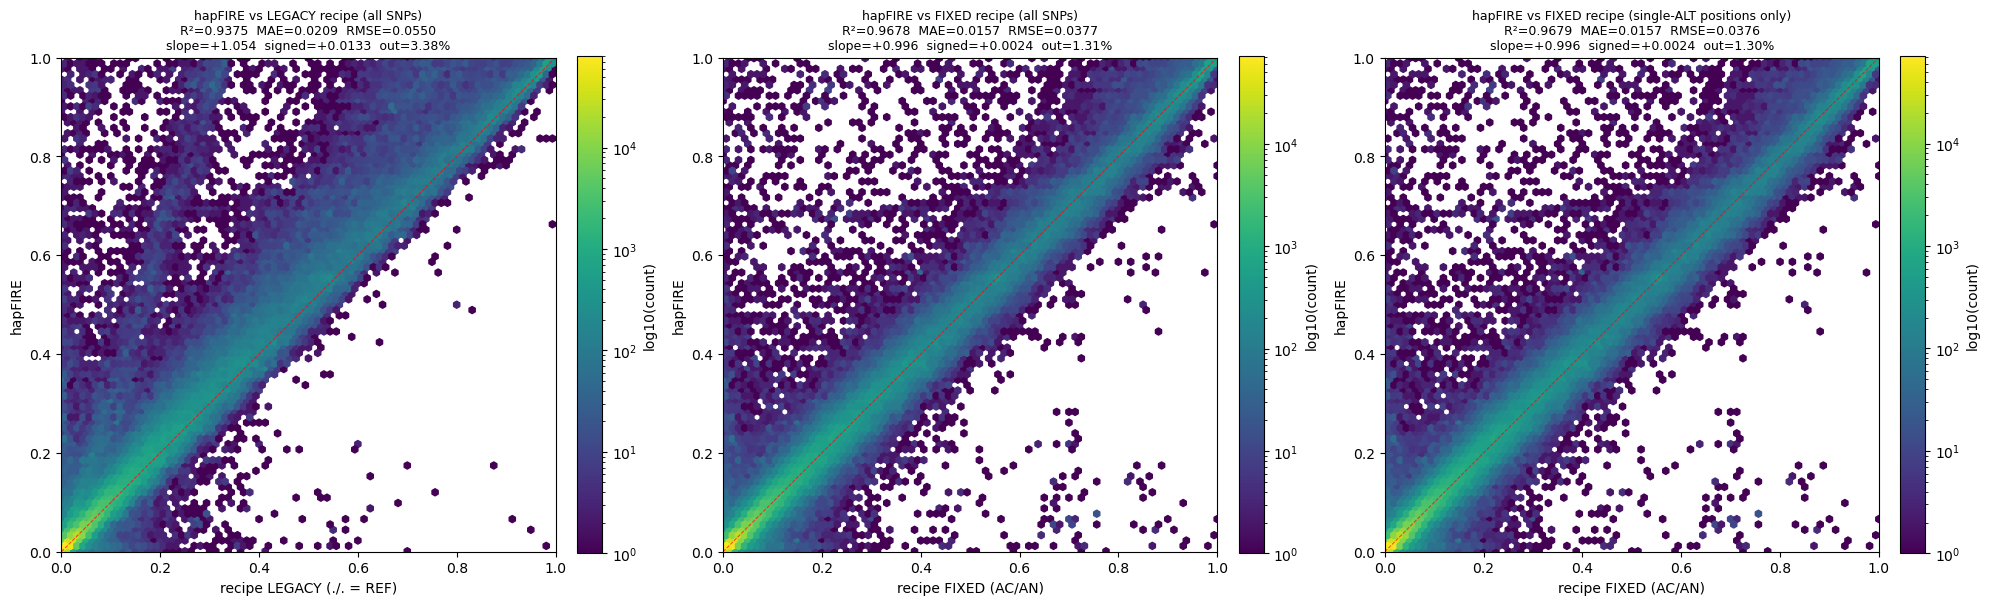

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
hexbin(axes[0], recipe_legacy, hf_af, 'recipe LEGACY (./. = REF)', 'hapFIRE',
       'hapFIRE vs LEGACY recipe (all SNPs)')
if recipe_fixed is not None:
    hexbin(axes[1], recipe_fixed, hf_af, 'recipe FIXED (AC/AN)', 'hapFIRE',
           'hapFIRE vs FIXED recipe (all SNPs)')
    hexbin(axes[2], recipe_fixed, hf_af, 'recipe FIXED (AC/AN)', 'hapFIRE',
           'hapFIRE vs FIXED recipe (single-ALT positions only)',
           mask=single_alt_mask)
else:
    axes[1].text(0.5, 0.5, 'cn_var_called not yet built', ha='center', va='center')
    axes[2].axis('off')
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_recipe_fix.png', dpi=130, bbox_inches='tight')
plt.show()

## Per-config scatter grid (vs FIXED recipe + vs hapFIRE)

Row 0 is hapFIRE itself for reference. Subsequent rows are each cactus_em config.

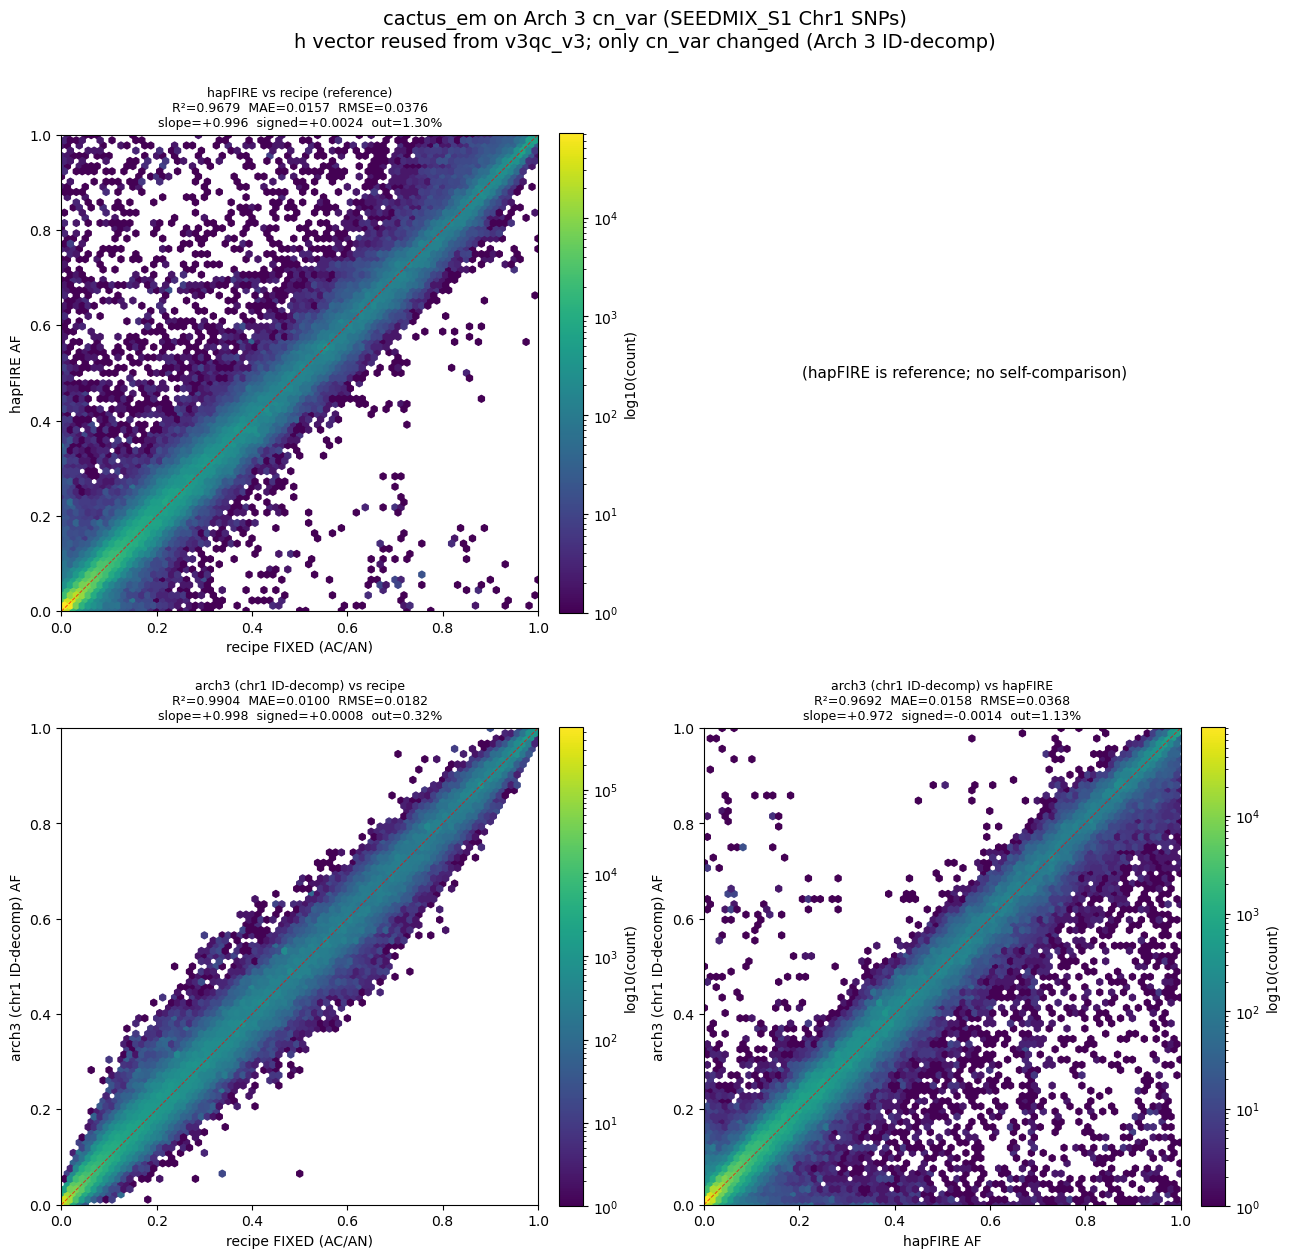

In [44]:
ref_truth = recipe_fixed if recipe_fixed is not None else recipe_legacy
ref_label = 'recipe FIXED (AC/AN)' if recipe_fixed is not None else 'recipe LEGACY'

method_names = list(cem_af.keys())
n_rows = 1 + len(method_names)
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 6.3 * n_rows))
if n_rows == 1:
    axes = np.atleast_2d(axes)

hexbin(axes[0, 0], ref_truth, hf_af, ref_label, 'hapFIRE AF',
       'hapFIRE vs recipe (reference)', mask=single_alt_mask)
axes[0, 1].axis('off')
axes[0, 1].text(0.5, 0.5, '(hapFIRE is reference; no self-comparison)',
                ha='center', va='center', fontsize=11, transform=axes[0, 1].transAxes)

for i, name in enumerate(method_names, start=1):
    cem = cem_af[name]
    hexbin(axes[i, 0], ref_truth, cem, ref_label, f'{name} AF',
           f'{name} vs recipe')
    hexbin(axes[i, 1], hf_af,    cem, 'hapFIRE AF',                f'{name} AF',
           f'{name} vs hapFIRE', mask=single_alt_mask)

fig.suptitle('cactus_em on Arch 3 cn_var (SEEDMIX_S1 Chr1 SNPs)\n'
             'h vector reused from v3qc_v3; only cn_var changed (Arch 3 ID-decomp)',
             y=0.999, fontsize=14)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_chr1.png', dpi=130, bbox_inches='tight')
plt.show()

## Summary table + Pareto

In [45]:
rows = []
m = metrics(ref_truth, hf_af, single_alt_mask)
if m is not None:
    rows.append({'method': 'hapFIRE', 'reference': ref_label, **{k:m[k] for k in ['n','r2','mae','rmse','slope','signed','out']}})
for name in method_names:
    cem = cem_af[name]
    for ref_name, ref_v, mk in [(ref_label, ref_truth, None), ('hapFIRE', hf_af, single_alt_mask)]:
        m = metrics(ref_v, cem, mk)
        if m is not None:
            rows.append({'method': name, 'reference': ref_name, **{k:m[k] for k in ['n','r2','mae','rmse','slope','signed','out']}})
tbl = pd.DataFrame(rows)
for col in ['r2','mae','rmse','slope','signed']:
    tbl[col] = tbl[col].map(lambda x: f'{x:.4f}')
tbl['out'] = tbl['out'].map(lambda x: f'{100*x:.2f}%')
print(tbl.to_string(index=False))

                method            reference       n     r2    mae   rmse  slope  signed   out
               hapFIRE recipe FIXED (AC/AN)  653614 0.9679 0.0157 0.0376 0.9961  0.0024 1.30%
arch3 (chr1 ID-decomp) recipe FIXED (AC/AN) 1896034 0.9904 0.0100 0.0182 0.9976  0.0008 0.32%
arch3 (chr1 ID-decomp)              hapFIRE  653614 0.9692 0.0158 0.0368 0.9723 -0.0014 1.13%


                config  h_bias  mae_vs_recipe_FIXED  mae_vs_hapFIRE
arch3 (chr1 ID-decomp)  2.2902               0.0100          0.0158


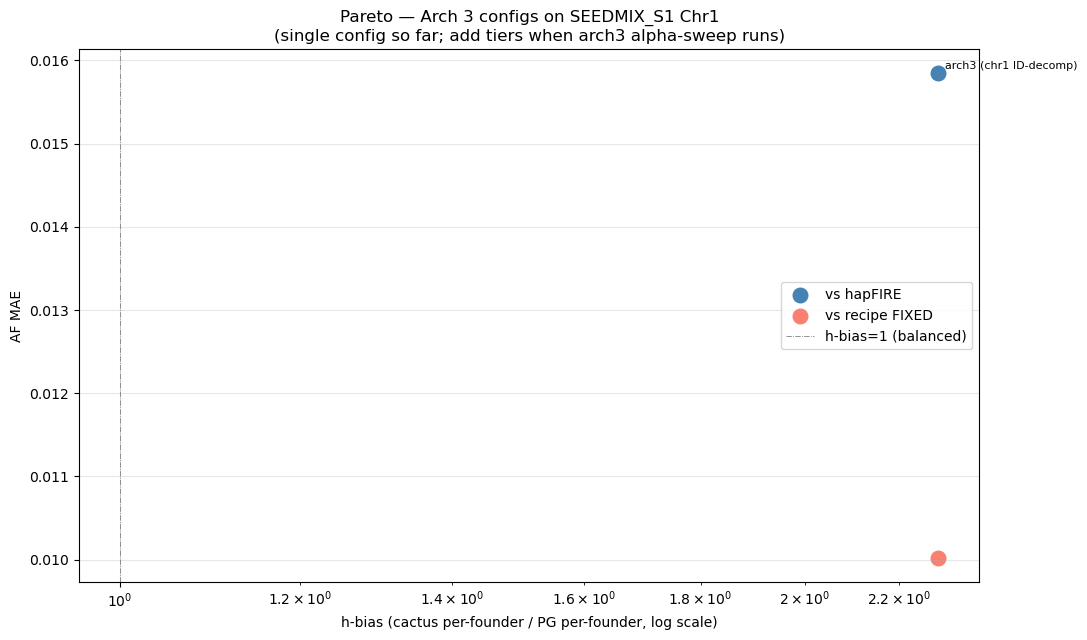

In [46]:
import json
with open(ROOT / 'data/founder_split_cactus_pg.json') as f:
    split = json.load(f)
cactus_set = set(map(str, split['cactus']))
pg_set = set(map(str, split['PG']))

def h_bias_from_npz(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    founders = list(d['founders'])
    h = d['Chr1']
    is_c = np.array([f in cactus_set for f in founders])
    is_p = np.array([f in pg_set for f in founders])
    pf_c = h[is_c].sum() / is_c.sum()
    pf_p = h[is_p].sum() / is_p.sum()
    return pf_c / pf_p if pf_p > 0 else np.nan

# Source h vector: the v3qc_v3 SEEDMIX_S1.h_per_chrom.npz that arch3 A6 re-projected
H_SRC = ROOT / 'scratch' / 'v3qc_v3_mixedloose_chr1' / 'SEEDMIX_S1.h_per_chrom.npz'

summary = []
for name in method_names:
    bias = h_bias_from_npz(H_SRC) if H_SRC.exists() else np.nan
    cem = cem_af[name]
    m_rec = metrics(ref_truth, cem)
    m_hf  = metrics(hf_af, cem, single_alt_mask)
    summary.append({
        'config': name, 'h_bias': bias,
        'mae_vs_recipe_FIXED': m_rec['mae'] if m_rec else np.nan,
        'mae_vs_hapFIRE':       m_hf['mae'] if m_hf else np.nan,
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False, float_format='%.4f'))

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(summary_df['h_bias'], summary_df['mae_vs_hapFIRE'], s=110, c='steelblue', label='vs hapFIRE')
ax.scatter(summary_df['h_bias'], summary_df['mae_vs_recipe_FIXED'], s=110, c='salmon', label='vs recipe FIXED')
for _, r in summary_df.iterrows():
    ax.annotate(r['config'], (r['h_bias'], r['mae_vs_hapFIRE']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')
ax.axvline(1.0, c='gray', ls='-.', lw=0.6, label='h-bias=1 (balanced)')
ax.set_xscale('log')
ax.set_xlabel('h-bias (cactus per-founder / PG per-founder, log scale)')
ax.set_ylabel('AF MAE')
ax.set_title('Pareto — Arch 3 configs on SEEDMIX_S1 Chr1\n(single config so far; add tiers when arch3 alpha-sweep runs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_pareto.png', dpi=130, bbox_inches='tight')
plt.show()

## Outlier diagnostic — same scatter colored by (1) genomic region, (2) F_MISSING

Reveal where the off-diagonal scatter cloud actually lives.

- **Region color**: Chr1 split into arm-p (1–14Mb), centromere (~14–17Mb), arm-q (17–30.5Mb)
- **F_MISSING color**: continuous, red = high missingness in arch3 cn_var at that record

n records plotted (single-ALT, in-range): 653,614


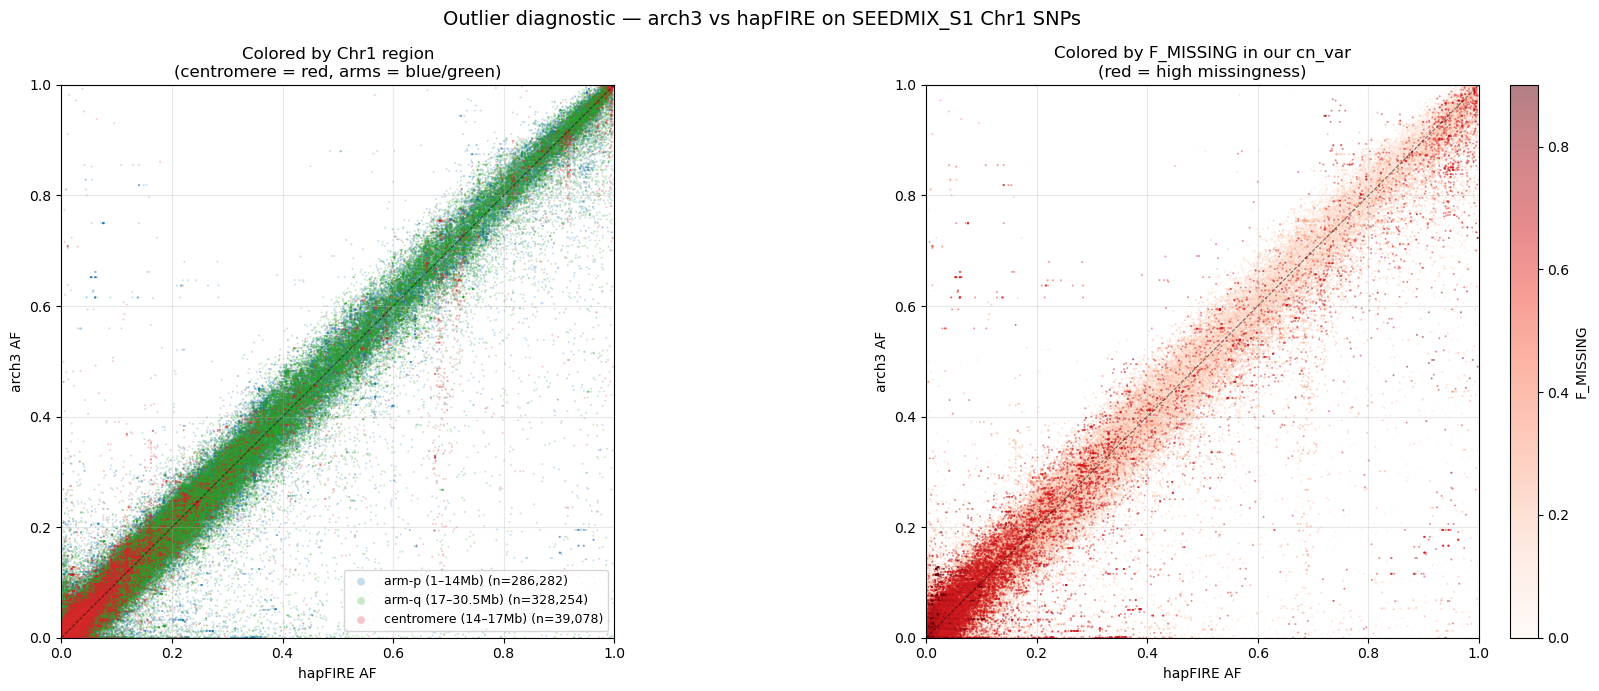


=== Outlier rate (|diff|>0.1) by region ===
  arm-p (1–14Mb): n=286,282, outliers=3,384 (1.18%)
  centromere (14–17Mb): n=39,078, outliers=921 (2.36%)
  arm-q (17–30.5Mb): n=328,254, outliers=3,096 (0.94%)

=== Outlier rate by F_MISSING bin ===
  F∈[0,0.01): n=317,930  outliers=  307  ( 0.10%)
  F∈[0.01,0.05): n=133,319  outliers=  946  ( 0.71%)
  F∈[0.05,0.1): n= 54,158  outliers=1,075  ( 1.98%)
  F∈[0.1,0.2): n= 69,492  outliers=1,762  ( 2.54%)
  F∈[0.2,0.5): n= 44,096  outliers=1,600  ( 3.63%)
  F∈[0.5,1.01): n= 34,619  outliers=1,711  ( 4.94%)


In [47]:
# Build aligned arrays for the arch3 vs hapFIRE scatter,
# enriched with genomic region and F_MISSING per record.
cem_v3 = cem_af['arch3 (chr1 ID-decomp)']
finite = np.isfinite(cem_v3) & np.isfinite(hf_af) & (cem_v3>=0) & (cem_v3<=1) & (hf_af>=0) & (hf_af<=1) & single_alt_mask
n_finite = int(finite.sum())
print(f'n records plotted (single-ALT, in-range): {n_finite:,}')

# Per-record carriers + called → F_MISSING
carriers_chr1 = cv_chr1.sum(axis=0)
called_chr1   = cvc_chr1.sum(axis=0)
fmiss_chr1    = 1 - called_chr1 / F

# Region label per record (Chr1 only; centromere ~14–17 Mb per BACKGROUND.md)
mb_chr1 = chr1_snp_pos / 1e6
region_labels = np.where(mb_chr1 < 14, 'arm-p (1–14Mb)',
                  np.where(mb_chr1 <= 17, 'centromere (14–17Mb)', 'arm-q (17–30.5Mb)'))

x_hf  = hf_af[finite]
y_cem = cem_v3[finite]
fm    = fmiss_chr1[finite]
reg   = region_labels[finite]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# --- Left: colored by region ---
ax = axes[0]
region_colors = {
    'arm-p (1–14Mb)':         '#1f77b4',
    'centromere (14–17Mb)':   '#d62728',
    'arm-q (17–30.5Mb)':      '#2ca02c',
}
# Plot arms first (background), centromere on top (foreground)
for label in ['arm-p (1–14Mb)', 'arm-q (17–30.5Mb)', 'centromere (14–17Mb)']:
    sel = reg == label
    ax.scatter(x_hf[sel], y_cem[sel], c=region_colors[label], s=2, alpha=0.25,
               edgecolor='none', label=f'{label} (n={sel.sum():,})')
ax.plot([0,1],[0,1],'k--', lw=0.7, alpha=0.6)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('arch3 AF')
ax.set_title('Colored by Chr1 region\n(centromere = red, arms = blue/green)')
ax.legend(loc='lower right', fontsize=9, markerscale=4)
ax.grid(alpha=0.3)

# --- Right: colored by F_MISSING continuous (red = high missingness) ---
ax = axes[1]
order = np.argsort(fm)  # plot high-F last so red dots are on top
sc = ax.scatter(x_hf[order], y_cem[order], c=fm[order], cmap='Reds', s=2, alpha=0.5,
                edgecolor='none', vmin=0, vmax=fm.max())
ax.plot([0,1],[0,1],'k--', lw=0.7, alpha=0.6)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('arch3 AF')
ax.set_title('Colored by F_MISSING in our cn_var\n(red = high missingness)')
plt.colorbar(sc, ax=ax, label='F_MISSING', fraction=0.046, pad=0.04)
ax.grid(alpha=0.3)

plt.suptitle('Outlier diagnostic — arch3 vs hapFIRE on SEEDMIX_S1 Chr1 SNPs',
             fontsize=14)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_outlier_colormap.png', dpi=140, bbox_inches='tight')
plt.show()

# Side-numerical breakdown
print('\n=== Outlier rate (|diff|>0.1) by region ===')
diff = y_cem - x_hf
for label in ['arm-p (1–14Mb)', 'centromere (14–17Mb)', 'arm-q (17–30.5Mb)']:
    sel = reg == label
    n = sel.sum(); n_out = (np.abs(diff[sel])>0.1).sum()
    print(f'  {label}: n={n:,}, outliers={n_out:,} ({n_out/n*100:.2f}%)')

print('\n=== Outlier rate by F_MISSING bin ===')
for lo, hi in [(0, 0.01), (0.01, 0.05), (0.05, 0.1), (0.1, 0.2), (0.2, 0.5), (0.5, 1.01)]:
    sel = (fm >= lo) & (fm < hi)
    n = sel.sum(); n_out = (np.abs(diff[sel])>0.1).sum() if n else 0
    pct = n_out/n*100 if n else 0
    print(f'  F∈[{lo},{hi}): n={n:>7,}  outliers={n_out:>5,}  ({pct:5.2f}%)')

## Outlier diagnostic — cem vs recipe FIXED, colored by F_MISSING

Same conventions as the cem-vs-hapFIRE diagnostic, but now the reference is the FIXED recipe (AC/AN projection). For arch3, cactus_em vs recipe is very tight (h ≈ uniform on SEEDMIX). Does the residual scatter correlate with F_MISSING?

n records plotted (vs FIXED recipe): 1,896,034


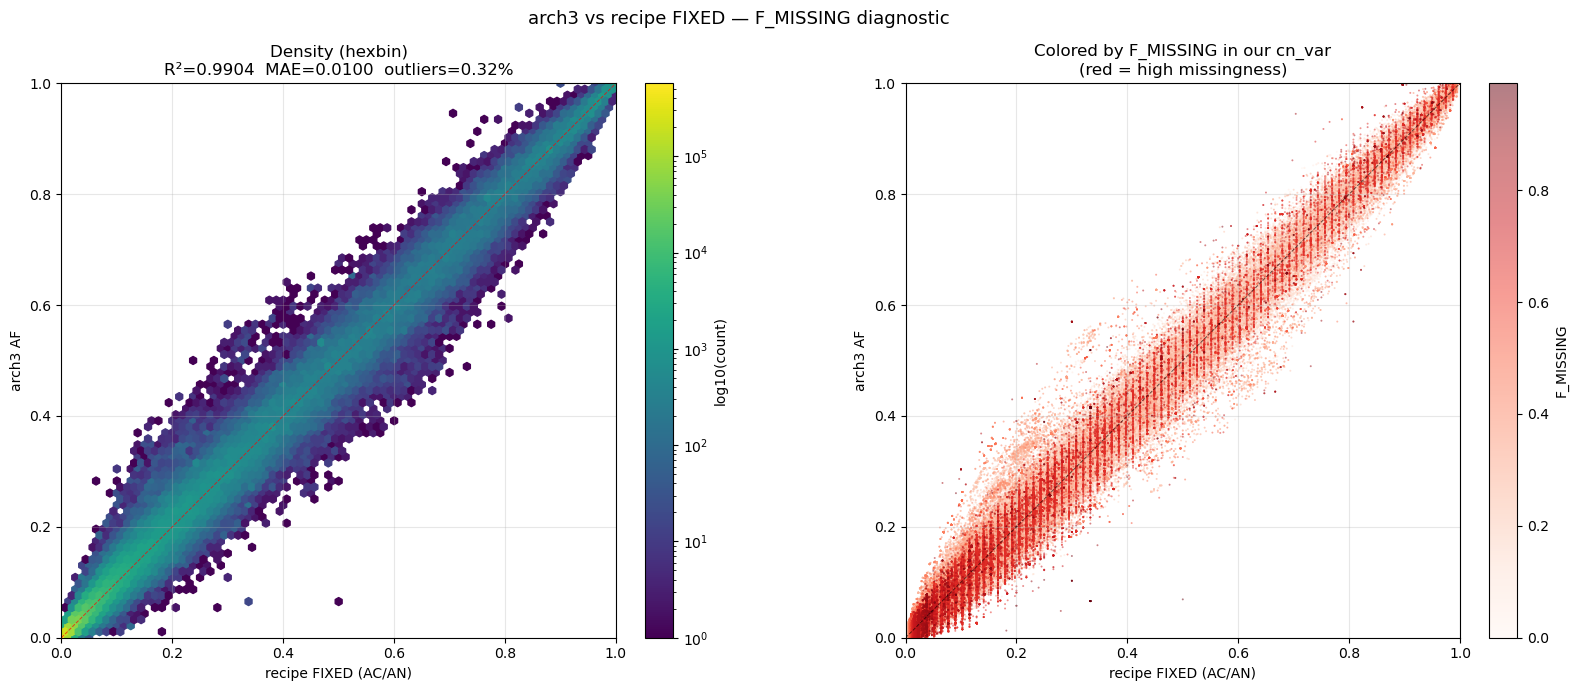


=== cem vs recipe FIXED: outlier rate by F_MISSING bin ===
  F∈[0,0.01): n=790,406  MAE=0.00558  outliers=  128 ( 0.02%)
  F∈[0.01,0.05): n=247,254  MAE=0.01427  outliers=  302 ( 0.12%)
  F∈[0.05,0.1): n=140,210  MAE=0.01585  outliers=  375 ( 0.27%)
  F∈[0.1,0.2): n=297,299  MAE=0.01132  outliers=  590 ( 0.20%)
  F∈[0.2,0.5): n=237,634  MAE=0.01357  outliers=3,620 ( 1.52%)
  F∈[0.5,1.01): n=183,231  MAE=0.01227  outliers=1,095 ( 0.60%)


In [48]:
# arch3 AF vs FIXED recipe, colored by F_MISSING.
# Use ALL records (not just single-ALT) since recipe truth doesn't have the
# hapFIRE multi-allelic-aliasing issue — recipe is per-record by construction.
cem_v3 = cem_af['arch3 (chr1 ID-decomp)']
finite_r = np.isfinite(cem_v3) & np.isfinite(ref_truth) & (cem_v3>=0) & (cem_v3<=1) & (ref_truth>=0) & (ref_truth<=1)
print(f'n records plotted (vs FIXED recipe): {finite_r.sum():,}')

x_rec = ref_truth[finite_r]
y_cem = cem_v3[finite_r]
fm    = fmiss_chr1[finite_r]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# --- Left: hexbin density (reference, no coloring) ---
ax = axes[0]
hb = ax.hexbin(x_rec, y_cem, gridsize=80, cmap='viridis', norm=LogNorm(), mincnt=1)
ax.plot([0,1],[0,1],'r--', lw=0.7, alpha=0.7)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('recipe FIXED (AC/AN)'); ax.set_ylabel('arch3 AF')
diff = y_cem - x_rec
mae = np.abs(diff).mean(); r2 = np.corrcoef(x_rec, y_cem)[0,1]**2
ax.set_title(f'Density (hexbin)\nR²={r2:.4f}  MAE={mae:.4f}  outliers={(np.abs(diff)>0.1).mean()*100:.2f}%')
plt.colorbar(hb, ax=ax, label='log10(count)', fraction=0.046, pad=0.04)
ax.grid(alpha=0.3)

# --- Right: same scatter colored by F_MISSING (red = high) ---
ax = axes[1]
order = np.argsort(fm)  # plot high-F last so red dots are on top
sc = ax.scatter(x_rec[order], y_cem[order], c=fm[order], cmap='Reds', s=2, alpha=0.5,
                edgecolor='none', vmin=0, vmax=fm.max())
ax.plot([0,1],[0,1],'k--', lw=0.7, alpha=0.6)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('recipe FIXED (AC/AN)'); ax.set_ylabel('arch3 AF')
ax.set_title('Colored by F_MISSING in our cn_var\n(red = high missingness)')
plt.colorbar(sc, ax=ax, label='F_MISSING', fraction=0.046, pad=0.04)
ax.grid(alpha=0.3)

plt.suptitle('arch3 vs recipe FIXED — F_MISSING diagnostic',
             fontsize=13)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_recipe_fmissing.png', dpi=140, bbox_inches='tight')
plt.show()

# Numerical stratification by F_MISSING bin
print('\n=== cem vs recipe FIXED: outlier rate by F_MISSING bin ===')
for lo, hi in [(0, 0.01), (0.01, 0.05), (0.05, 0.1), (0.1, 0.2), (0.2, 0.5), (0.5, 1.01)]:
    sel = (fm >= lo) & (fm < hi)
    n = sel.sum()
    if n == 0:
        continue
    sub_mae = np.abs(diff[sel]).mean()
    n_out = (np.abs(diff[sel]) > 0.1).sum()
    pct_out = n_out/n*100
    print(f'  F∈[{lo},{hi}): n={n:>7,}  MAE={sub_mae:.5f}  outliers={n_out:>5,} ({pct_out:5.2f}%)')

## Atomization — closing the encoding-disagreement gap

Per-base atomized cn_var built by unioning founder carriers across all biallelic source records that imply each `(pos, ref_base, alt_base)` substitution. MNP `AC>TA` at pos N contributes carriers to two atomic SNPs: `A>T` at pos N and `C>A` at pos N+1. SNPs are unchanged. INS/DEL contribute only their overlap region.

This is the SNP-centric view appropriate for cross-study GWAS/GEA comparison with 1001G-based catalogs.

In [49]:
# --- Load atomized cn_var + meta ---
ATOM = ARCH / 'cn_var_231_arch3_chr1_atomized'
meta_a = np.load(f'{ATOM}.meta.npz', allow_pickle=True)
atom_pos   = np.asarray(meta_a['pos']).astype(np.int64)
atom_ref   = np.asarray(meta_a['ref'], dtype=object)
atom_alt   = np.asarray(meta_a['alt'], dtype=object)
atom_chrom = np.asarray(meta_a['chrom']).astype(str)
cn_var_a       = load_npz(f'{ATOM}.cn_var.npz')
cn_var_called_a = load_npz(f'{ATOM}.cn_var_called.npz')
print(f'atomized cn_var: {cn_var_a.shape}, {cn_var_a.nnz:,} nnz')
print(f'atomized cn_var_called: {cn_var_called_a.shape}, {cn_var_called_a.nnz:,} nnz')
print(f'atomized records: {len(atom_pos):,}')

# Per-position atomic count (how many ALT substitutions at each pos)
from collections import Counter
atom_pos_counts = Counter(atom_pos.tolist())
print(f'positions with >1 atomic ALT (triallelic+): {sum(1 for v in atom_pos_counts.values() if v>1):,}')

# Recipe truth on atomized cn_var (uniform-h, AC/AN with called mask)
TRUTH_H_a = np.full(cn_var_a.shape[0], 1.0/cn_var_a.shape[0], dtype=np.float32)
# Sparse @ vector is cheap; we just need the dense result vector
numer_a = (TRUTH_H_a @ cn_var_a).A1 if hasattr(TRUTH_H_a @ cn_var_a, 'A1') else (TRUTH_H_a @ cn_var_a)
denom_a = (TRUTH_H_a @ cn_var_called_a).A1 if hasattr(TRUTH_H_a @ cn_var_called_a, 'A1') else (TRUTH_H_a @ cn_var_called_a)
recipe_atom = np.where(denom_a > 0, numer_a / denom_a, np.nan).astype(np.float32)

# Load atomized cactus_em projection (D2 output)
sm_atom = pd.read_csv(ARCH / 'SEEDMIX_S1_arch3_chr1_atomized.tsv', sep='\t')
cem_atom = sm_atom['alt_freq'].to_numpy(dtype=np.float32)
print(f'cactus_em atomized AF rows: {len(cem_atom):,}')

# Build per-atom hapFIRE alignment via 4-tuple
atom_ref_s = [str(r) for r in atom_ref]
atom_alt_s = [str(a) for a in atom_alt]
hf_atom = np.array(
    [hf_key.get((int(atom_pos[i]), atom_ref_s[i], atom_alt_s[i]), np.nan) for i in range(len(atom_pos))],
    dtype=np.float32
)
print(f'hapFIRE aligned to atomized 4-tuple: n_finite={np.isfinite(hf_atom).sum():,} / {len(hf_atom):,}')

atomized cn_var: (231, 7464709), 76,920,922 nnz
atomized cn_var_called: (231, 7464709), 1,178,293,839 nnz
atomized records: 7,464,709
positions with >1 atomic ALT (triallelic+): 1,836,377
cactus_em atomized AF rows: 7,464,709
hapFIRE aligned to atomized 4-tuple: n_finite=711,669 / 7,464,709


cactus_em atomized AF rows: 7,464,709


hapFIRE aligned to atomized 4-tuple: n_finite=711,669 / 7,464,709


## Atomized vs raw scatter — side by side

/tmp/ipykernel_559994/3833774023.py:13: RankWarning: Polyfit may be poorly conditioned
  slope=float(np.polyfit(xv, yv, 1)[0]),


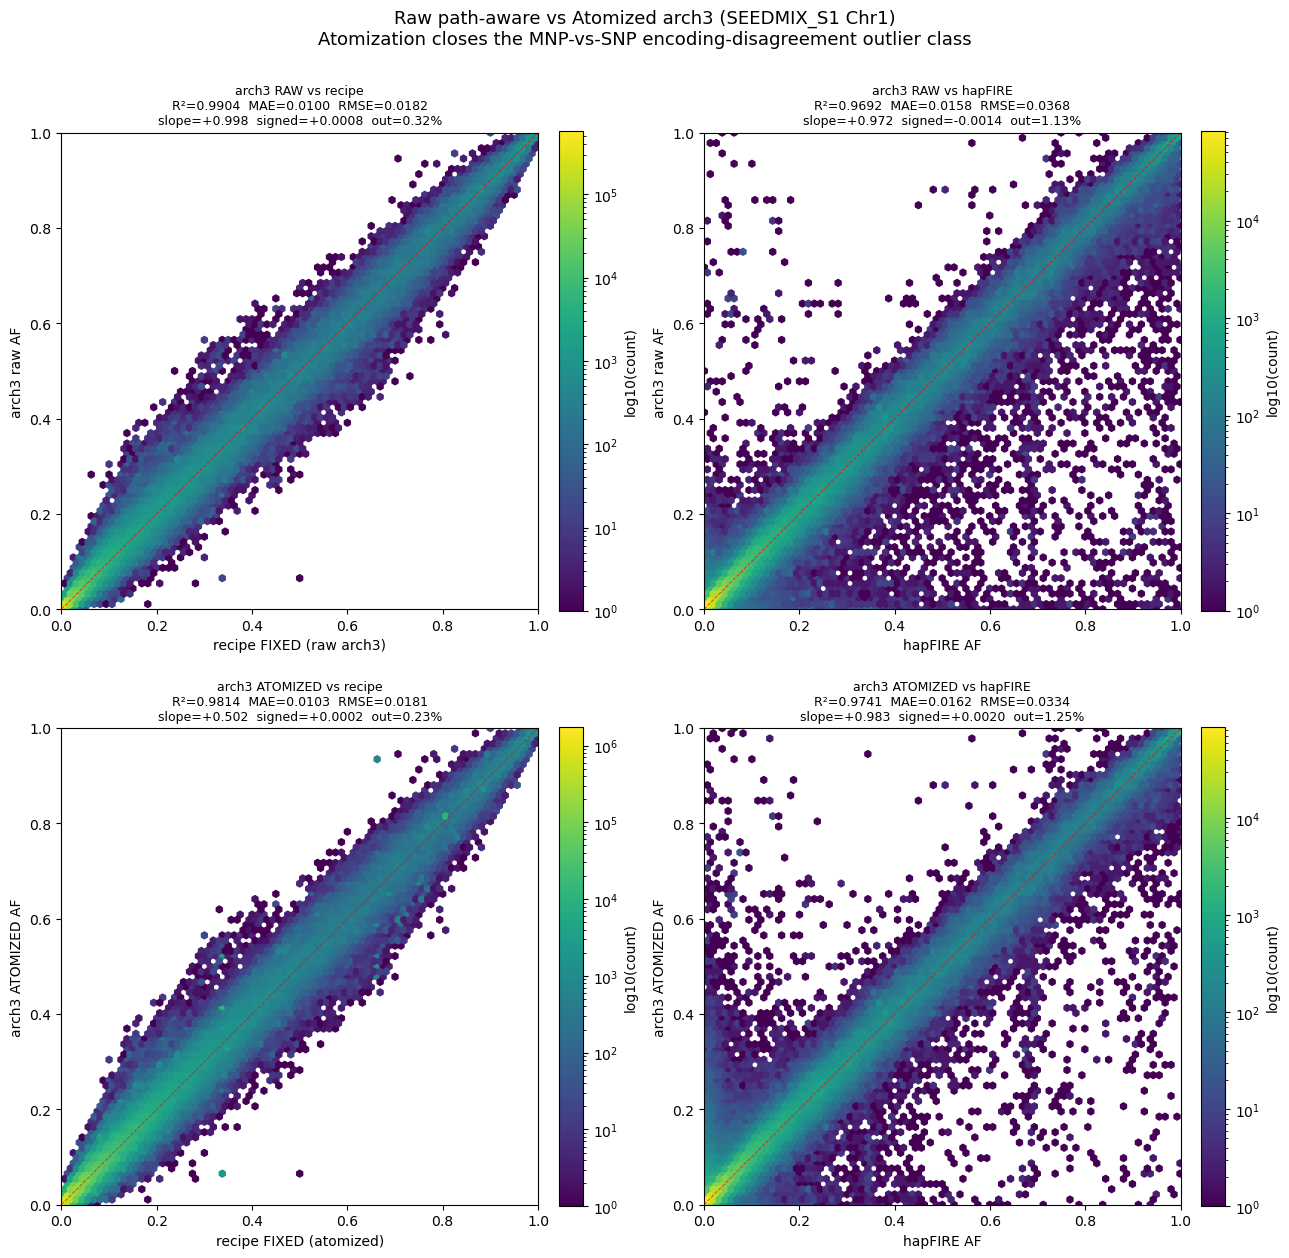

In [50]:
# Build a clean 2×2: top row uses RAW arch3 (path-aware), bottom uses ATOMIZED.
# Left column: vs FIXED recipe; right column: vs hapFIRE.
fig, axes = plt.subplots(2, 2, figsize=(13, 12.6))

# --- TOP ROW: RAW path-aware ---
hexbin(axes[0, 0], recipe_fixed, cem_af['arch3 (chr1 ID-decomp)'],
       'recipe FIXED (raw arch3)', 'arch3 raw AF',
       'arch3 RAW vs recipe')
hexbin(axes[0, 1], hf_af, cem_af['arch3 (chr1 ID-decomp)'],
       'hapFIRE AF', 'arch3 raw AF',
       'arch3 RAW vs hapFIRE',
       mask=single_alt_mask)

# --- BOTTOM ROW: ATOMIZED ---
hexbin(axes[1, 0], recipe_atom, cem_atom,
       'recipe FIXED (atomized)', 'arch3 ATOMIZED AF',
       'arch3 ATOMIZED vs recipe')
hexbin(axes[1, 1], hf_atom, cem_atom,
       'hapFIRE AF', 'arch3 ATOMIZED AF',
       'arch3 ATOMIZED vs hapFIRE')

plt.suptitle('Raw path-aware vs Atomized arch3 (SEEDMIX_S1 Chr1)\n'
             'Atomization closes the MNP-vs-SNP encoding-disagreement outlier class',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_atomized_vs_raw.png', dpi=130, bbox_inches='tight')
plt.show()

## Outlier transitions — which raw outliers does atomization fix?

From the D2 head-to-head (519k shared 4-tuple SNPs):
- 1,624 raw outliers FIXED by atomization (48.6% of raw outliers)
- 174 outliers INTRODUCED by atomization
- 1,720 outliers REMAIN — these are panel-vs-1001G genuine GT disagreement; no encoding fix can resolve

Top fixed outliers below — all SNPs at positions where carriers were locked inside an adjacent MNP row in the raw cn_var.

3-way join (atomized ∩ arch3_raw ∩ hapFIRE): 518,570

=== Outlier transition matrix (|Δ|>0.10) ===
  raw OK,   atomized OK:   515,052  (99.32%)
  raw out,  atomized OK:     1,624  (0.31%)  ← FIXED by atomization
  raw OK,   atomized out:      174  (0.03%)  ← INTRODUCED by atomization
  raw out,  atomized out:    1,720  (0.33%)  ← still outlier (panel-vs-1001G GT)


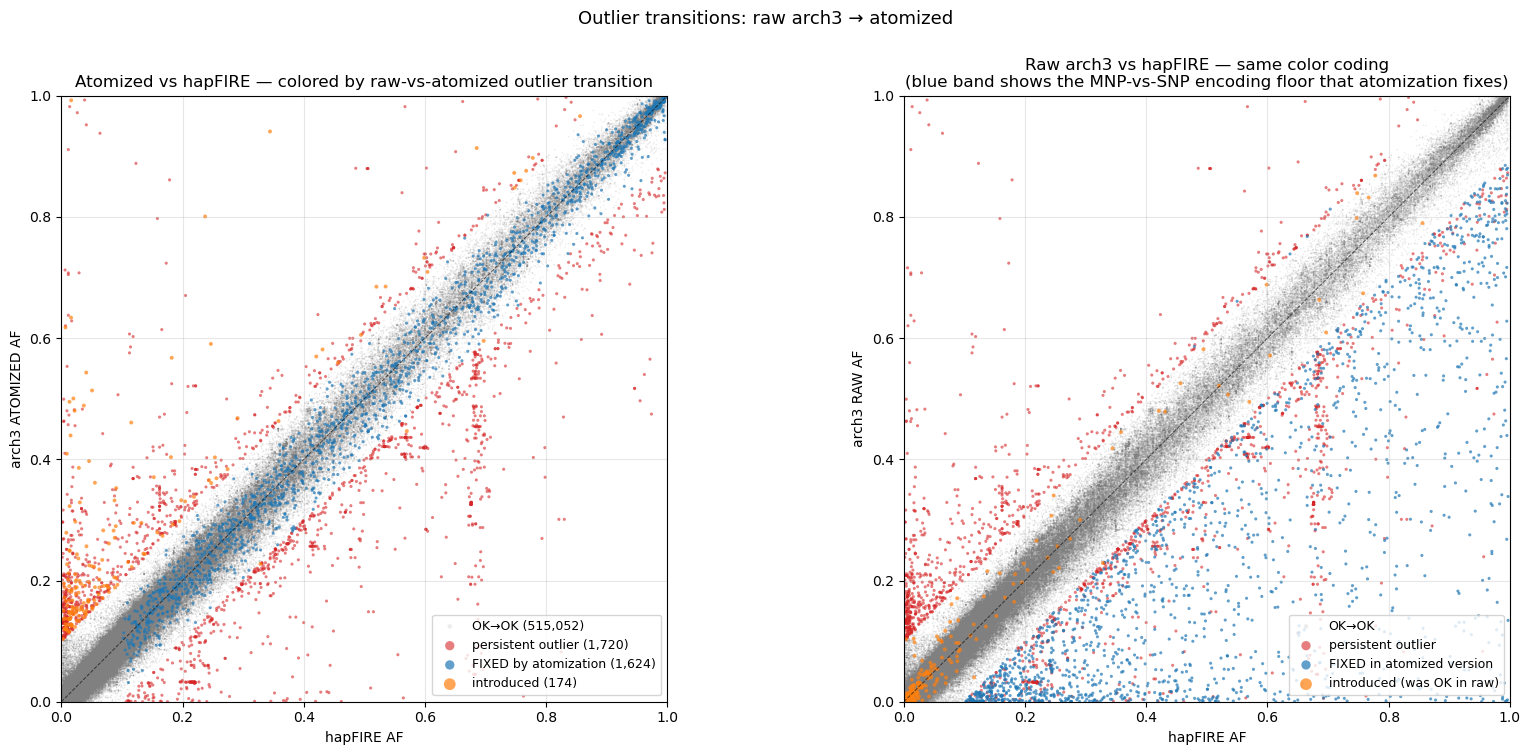


=== Head-to-head MAE / RMSE / outliers ===
  arch3 raw vs hF           MAE=0.0140  RMSE=0.0294  bias=-0.0004  |Δ|>0.10: 3,344 (0.64%)
  arch3 ATOMIZED vs hF      MAE=0.0131  RMSE=0.0225  bias=+0.0009  |Δ|>0.10: 1,894 (0.37%)


In [51]:
# Load the D2 3-way comparison and show the transition
cmp = pd.read_csv(ARCH / 'SEEDMIX_S1_chr1_atomized_AF_compare.tsv', sep='\t')
print(f'3-way join (atomized ∩ arch3_raw ∩ hapFIRE): {len(cmp):,}')

d_raw  = cmp['af_arch3_raw'] - cmp['af_hapfire']
d_atom = cmp['af_atomized']  - cmp['af_hapfire']
raw_out  = np.abs(d_raw)  > 0.10
atom_out = np.abs(d_atom) > 0.10
fixed     = raw_out & ~atom_out
introduced = ~raw_out & atom_out
both      = raw_out & atom_out
neither   = ~raw_out & ~atom_out

print()
print('=== Outlier transition matrix (|Δ|>0.10) ===')
print(f'  raw OK,   atomized OK:   {neither.sum():>7,}  ({100*neither.sum()/len(cmp):.2f}%)')
print(f'  raw out,  atomized OK:   {fixed.sum():>7,}  ({100*fixed.sum()/len(cmp):.2f}%)  ← FIXED by atomization')
print(f'  raw OK,   atomized out:  {introduced.sum():>7,}  ({100*introduced.sum()/len(cmp):.2f}%)  ← INTRODUCED by atomization')
print(f'  raw out,  atomized out:  {both.sum():>7,}  ({100*both.sum()/len(cmp):.2f}%)  ← still outlier (panel-vs-1001G GT)')

# Scatter overlay: highlight the fixed + introduced outliers in (hapFIRE, atomized) space
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))

ax = axes[0]
ax.scatter(cmp.loc[neither, 'af_hapfire'], cmp.loc[neither, 'af_atomized'],
           s=1.2, alpha=0.15, c='gray', edgecolor='none', label=f'OK→OK ({neither.sum():,})')
ax.scatter(cmp.loc[both, 'af_hapfire'], cmp.loc[both, 'af_atomized'],
           s=5, alpha=0.6, c='#d62728', edgecolor='none', label=f'persistent outlier ({both.sum():,})')
ax.scatter(cmp.loc[fixed, 'af_hapfire'], cmp.loc[fixed, 'af_atomized'],
           s=5, alpha=0.7, c='#1f77b4', edgecolor='none', label=f'FIXED by atomization ({fixed.sum():,})')
ax.scatter(cmp.loc[introduced, 'af_hapfire'], cmp.loc[introduced, 'af_atomized'],
           s=8, alpha=0.7, c='#ff7f0e', edgecolor='none', label=f'introduced ({introduced.sum():,})')
ax.plot([0,1],[0,1],'k--',lw=0.7,alpha=0.6)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('arch3 ATOMIZED AF')
ax.set_title(f'Atomized vs hapFIRE — colored by raw-vs-atomized outlier transition')
ax.legend(loc='lower right', fontsize=9, markerscale=3)
ax.grid(alpha=0.3)

# Right panel: arch3 raw — same positions colored same way
ax = axes[1]
ax.scatter(cmp.loc[neither, 'af_hapfire'], cmp.loc[neither, 'af_arch3_raw'],
           s=1.2, alpha=0.15, c='gray', edgecolor='none', label=f'OK→OK')
ax.scatter(cmp.loc[both, 'af_hapfire'], cmp.loc[both, 'af_arch3_raw'],
           s=5, alpha=0.6, c='#d62728', edgecolor='none', label=f'persistent outlier')
ax.scatter(cmp.loc[fixed, 'af_hapfire'], cmp.loc[fixed, 'af_arch3_raw'],
           s=5, alpha=0.7, c='#1f77b4', edgecolor='none', label=f'FIXED in atomized version')
ax.scatter(cmp.loc[introduced, 'af_hapfire'], cmp.loc[introduced, 'af_arch3_raw'],
           s=8, alpha=0.7, c='#ff7f0e', edgecolor='none', label=f'introduced (was OK in raw)')
ax.plot([0,1],[0,1],'k--',lw=0.7,alpha=0.6)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('arch3 RAW AF')
ax.set_title(f'Raw arch3 vs hapFIRE — same color coding\n(blue band shows the MNP-vs-SNP encoding floor that atomization fixes)')
ax.legend(loc='lower right', fontsize=9, markerscale=3)
ax.grid(alpha=0.3)

plt.suptitle('Outlier transitions: raw arch3 → atomized', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_outlier_transitions.png', dpi=140, bbox_inches='tight')
plt.show()

# Headline metrics table
print()
print('=== Head-to-head MAE / RMSE / outliers ===')
for name, d in [('arch3 raw vs hF', d_raw), ('arch3 ATOMIZED vs hF', d_atom)]:
    mae = np.abs(d).mean(); rmse = np.sqrt((d**2).mean()); bias = d.mean()
    nout = (np.abs(d)>0.10).sum()
    print(f'  {name:<24}  MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}  |Δ|>0.10: {nout:,} ({100*nout/len(d):.2f}%)')

## h-vector sensitivity — does the inferred h depend on the EM filter tier?

We've been projecting **h from v3qc_v3 mixed-loose** through both the raw arch3 cn_var and the atomized cn_var. Question: what if we use a different h vector? Compare:

- **h raw**: from `seedmix_v3qc_dedup/SEEDMIX_S1.h_per_chrom.npz` — v3qc base run, no k-mer subset filter (`run_seedmix_v3qc.sh`).
- **h mixed-loose**: from `v3qc_v3_mixedloose_chr1/SEEDMIX_S1.h_per_chrom.npz` — v3qc-v3 panel with ac_cactus≥1+ac_pg≥1 k-mer filter (the canonical one).

Both projected through the same raw arch3 cn_var. If the two h vectors are similar → seed-mix composition is robust to EM filter choice; differences are at the floor. If they differ → filter choice has real downstream impact on AF estimates.

h_raw       : sum=1.0000  std=6.45e-03  CV=1.489
h_mixedloose: sum=1.0000  std=4.13e-03  CV=0.954
founder ordering match: True

h_raw vs h_mixedloose: Pearson r = 0.645970
  max |h_raw - h_ml|: 2.1004e-02
  mean |h_raw - h_ml|: 3.5220e-03

=== h-bias per class ===
h_raw       :  cactus_per_founder=1.1741e-02  PG_per_founder=4.0232e-04  ratio=29.182
h_mixedloose:  cactus_per_founder=6.8525e-03  PG_per_founder=2.9921e-03  ratio=2.290

AF projection (SNP-sliced, len=1,896,034):
  h_raw       : [0.0000, 1.0000]
  h_mixedloose: [0.0000, 1.0000]

=== Metrics ===

  vs hapFIRE:
    h_raw projection            n= 653,614  R²=0.9622  MAE=0.0216  bias=+0.0027  out=1.70%
    h_mixedloose projection     n= 653,614  R²=0.9692  MAE=0.0158  bias=-0.0014  out=1.13%

  vs recipe:
    h_raw projection            n=1,896,034  R²=0.9615  MAE=0.0152  bias=+0.0050  out=1.54%
    h_mixedloose projection     n=1,896,034  R²=0.9904  MAE=0.0100  bias=+0.0008  out=0.32%

=== h_mixedloose projection vs h_raw proj

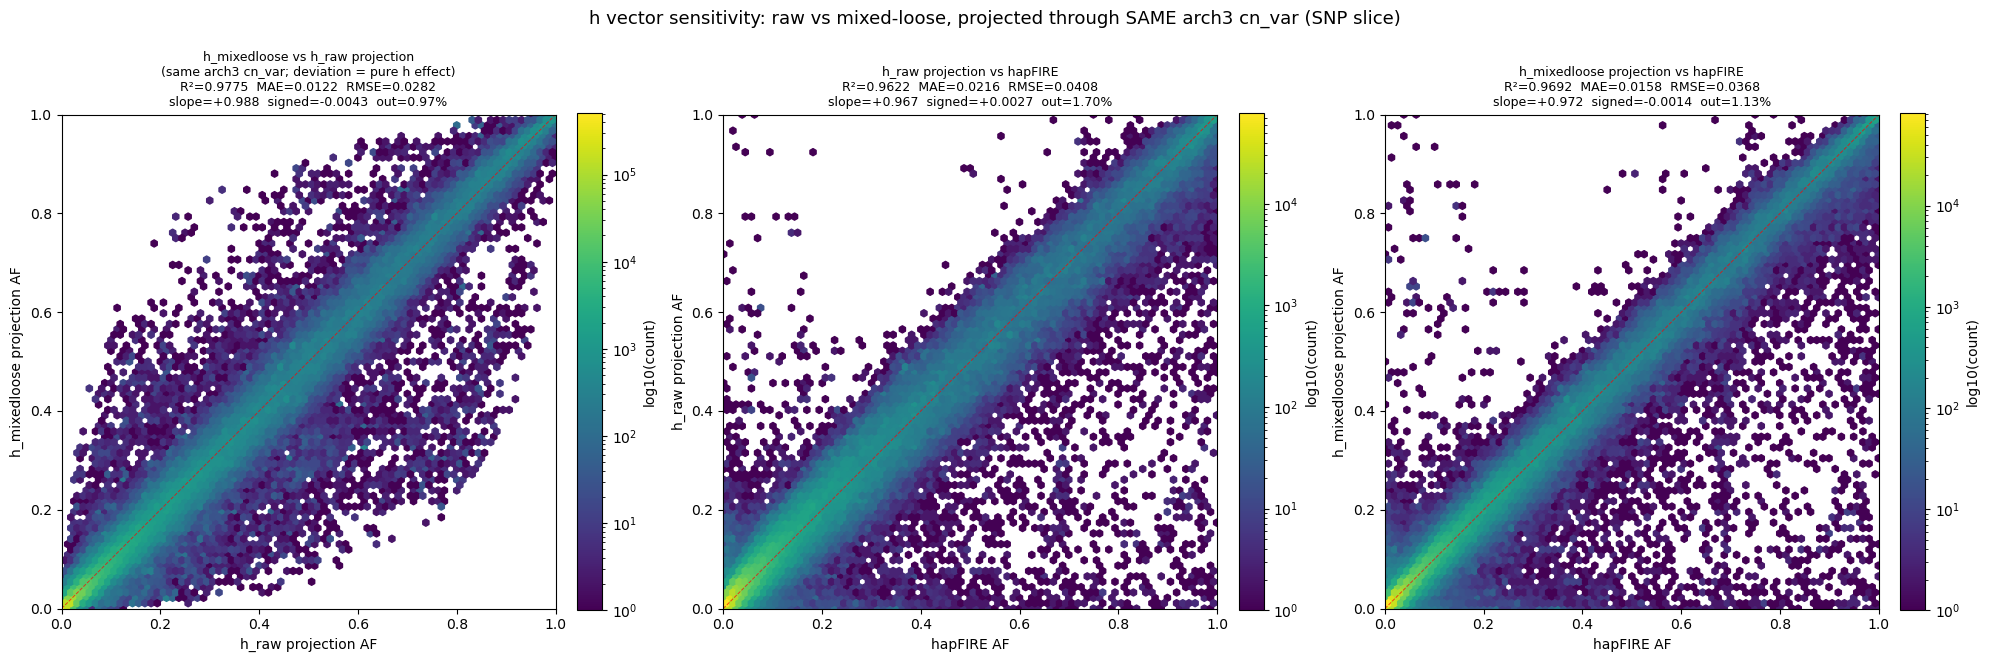

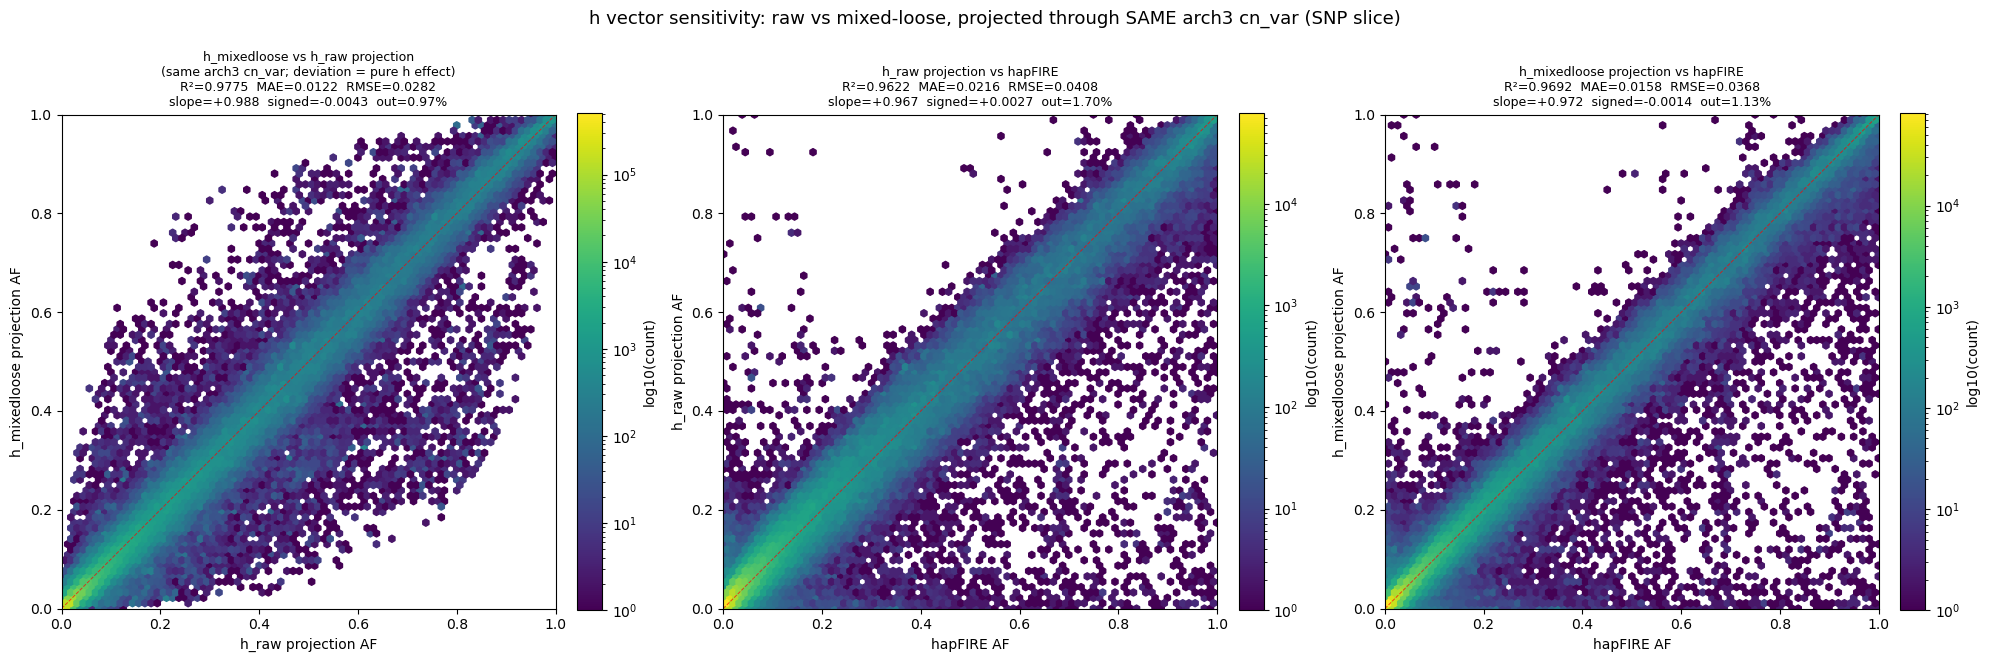

In [52]:
# Load both h vectors + project through raw arch3 cn_var (SNP-sliced for alignment with hf_af / recipe_fixed)
H_RAW = ROOT / 'scratch' / 'seedmix_v3qc_dedup' / 'SEEDMIX_S1.h_per_chrom.npz'
H_ML  = ROOT / 'scratch' / 'v3qc_v3_mixedloose_chr1' / 'SEEDMIX_S1.h_per_chrom.npz'

def load_h(path):
    d = np.load(path, allow_pickle=True)
    return d['Chr1'].astype(np.float64), list(d['founders'])

h_raw, fnd_raw = load_h(H_RAW)
h_ml,  fnd_ml  = load_h(H_ML)
print(f'h_raw       : sum={h_raw.sum():.4f}  std={h_raw.std():.2e}  CV={h_raw.std()/h_raw.mean():.3f}')
print(f'h_mixedloose: sum={h_ml.sum():.4f}  std={h_ml.std():.2e}  CV={h_ml.std()/h_ml.mean():.3f}')
print(f'founder ordering match: {fnd_raw == fnd_ml}')

# h-vector correlation
r_h = np.corrcoef(h_raw, h_ml)[0,1]
print(f'\nh_raw vs h_mixedloose: Pearson r = {r_h:.6f}')
print(f'  max |h_raw - h_ml|: {np.abs(h_raw - h_ml).max():.4e}')
print(f'  mean |h_raw - h_ml|: {np.abs(h_raw - h_ml).mean():.4e}')

# Per-class h sums
import json as _json
with open(ROOT / 'data/founder_split_cactus_pg.json') as f:
    _spl = _json.load(f)
_c_set = set(map(str, _spl['cactus'])); _p_set = set(map(str, _spl['PG']))
is_c = np.array([str(s) in _c_set for s in fnd_raw])
is_p = np.array([str(s) in _p_set for s in fnd_raw])
print(f'\n=== h-bias per class ===')
print(f'h_raw       :  cactus_per_founder={h_raw[is_c].mean():.4e}  PG_per_founder={h_raw[is_p].mean():.4e}  ratio={h_raw[is_c].mean()/h_raw[is_p].mean():.3f}')
print(f'h_mixedloose:  cactus_per_founder={h_ml[is_c].mean():.4e}  PG_per_founder={h_ml[is_p].mean():.4e}  ratio={h_ml[is_c].mean()/h_ml[is_p].mean():.3f}')

# Project through SNP-sliced cn_var (cv_chr1 / cvc_chr1 from cell 2 are already (F, n_snps) dense)
# cv_chr1: dense float32 (F, n_chr1_snps)
# cvc_chr1: dense float32 (F, n_chr1_snps)
def project_snp(h_):
    n = h_.astype(np.float32) @ cv_chr1
    d = h_.astype(np.float32) @ cvc_chr1
    return np.where(d > 0, n / d, np.nan).astype(np.float32)

af_raw_h = project_snp(h_raw)
af_ml_h  = project_snp(h_ml)
print(f'\nAF projection (SNP-sliced, len={len(af_raw_h):,}):')
print(f'  h_raw       : [{np.nanmin(af_raw_h):.4f}, {np.nanmax(af_raw_h):.4f}]')
print(f'  h_mixedloose: [{np.nanmin(af_ml_h):.4f}, {np.nanmax(af_ml_h):.4f}]')

# Metrics: each h vs hapFIRE, each h vs recipe_fixed
print('\n=== Metrics ===')
for name, ref_v, mk in [
    ('vs hapFIRE',  hf_af,        single_alt_mask),
    ('vs recipe',   recipe_fixed, None),
]:
    print(f'\n  {name}:')
    for h_name, cem in [('h_raw projection', af_raw_h), ('h_mixedloose projection', af_ml_h)]:
        m = metrics(ref_v, cem, mk)
        if m is not None:
            print(f'    {h_name:<26}  n={m["n"]:>8,}  R²={m["r2"]:.4f}  MAE={m["mae"]:.4f}  bias={m["signed"]:+.4f}  out={100*m["out"]:.2f}%')

# Direct: h_raw projection vs h_mixedloose projection
finite = np.isfinite(af_raw_h) & np.isfinite(af_ml_h)
d = af_ml_h[finite] - af_raw_h[finite]
print(f'\n=== h_mixedloose projection vs h_raw projection (same arch3 cn_var SNP slice) ===')
print(f'  records compared: {finite.sum():,}')
print(f'  MAE: {np.abs(d).mean():.4f}')
print(f'  RMSE: {np.sqrt((d**2).mean()):.4f}')
print(f'  |Δ|>0.10: {(np.abs(d)>0.10).sum():,} ({100*(np.abs(d)>0.10).sum()/finite.sum():.3f}%)')
print(f'  Pearson r: {np.corrcoef(af_raw_h[finite], af_ml_h[finite])[0,1]:.6f}')

# Three-panel scatter: h_raw vs h_ml; h_raw vs hapFIRE; h_ml vs hapFIRE
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
hexbin(axes[0], af_raw_h, af_ml_h, 'h_raw projection AF', 'h_mixedloose projection AF',
       'h_mixedloose vs h_raw projection\n(same arch3 cn_var; deviation = pure h effect)')
hexbin(axes[1], hf_af, af_raw_h, 'hapFIRE AF', 'h_raw projection AF',
       'h_raw projection vs hapFIRE', mask=single_alt_mask)
hexbin(axes[2], hf_af, af_ml_h, 'hapFIRE AF', 'h_mixedloose projection AF',
       'h_mixedloose projection vs hapFIRE', mask=single_alt_mask)
plt.suptitle('h vector sensitivity: raw vs mixed-loose, projected through SAME arch3 cn_var (SNP slice)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_h_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()


## h-filt2 — adding filt2 k-mer filter tier

A new h vector was computed using the **filt2** k-mer filter: `v3qc_v3_filt2_chr1/SEEDMIX_S1.h_per_chrom.npz`.  
Compare vs mixed-loose (the prior canonical h) and vs hapFIRE on the atomized cn_var 4-tuple join.

Key questions:
- Does filt2 reduce MAE / outliers vs hapFIRE?
- Does filt2 reduce the cactus h-bias?
- How does filt2 AF compare to recipe (uniform h) on the SNP-sliced cn_var?


=== h-vector stats ===
  mixedloose    CV=0.9539  cactus/PG per-founder ratio=2.2902  cactus_sum=0.5482 (unif=0.3463)
  filt2         CV=0.8672  cactus/PG per-founder ratio=1.9131  cactus_sum=0.5034 (unif=0.3463)

h_mixedloose vs h_filt2: Pearson r = 0.952290  max|Δ|=6.9471e-03

=== Metrics vs recipe (SNP-sliced cn_var) ===
  h_mixedloose    n=1,896,034  R²=0.9904  MAE=0.0100  RMSE=0.0182  bias=+0.0008  out=0.32%
  h_filt2         n=1,896,034  R²=0.9926  MAE=0.0087  RMSE=0.0160  bias=+0.0009  out=0.16%

=== Metrics vs hapFIRE (SNP-sliced cn_var, single-ALT mask) ===
  h_mixedloose    n= 653,614  R²=0.9692  MAE=0.0158  RMSE=0.0368  bias=-0.0014  out=1.13%
  h_filt2         n= 653,614  R²=0.9699  MAE=0.0151  RMSE=0.0363  bias=-0.0012  out=1.12%

=== hapFIRE comparison via atomized cn_var (F1 job output) ===
  4-tuple records: 711,669
  h_mixedloose    MAE=0.0162  RMSE=0.0334  bias=+0.0020  |Δ|>0.10:8,900 (1.25%)
  h_filt2         MAE=0.0154  RMSE=0.0330  bias=+0.0022  |Δ|>0.10:8,812 (1.2

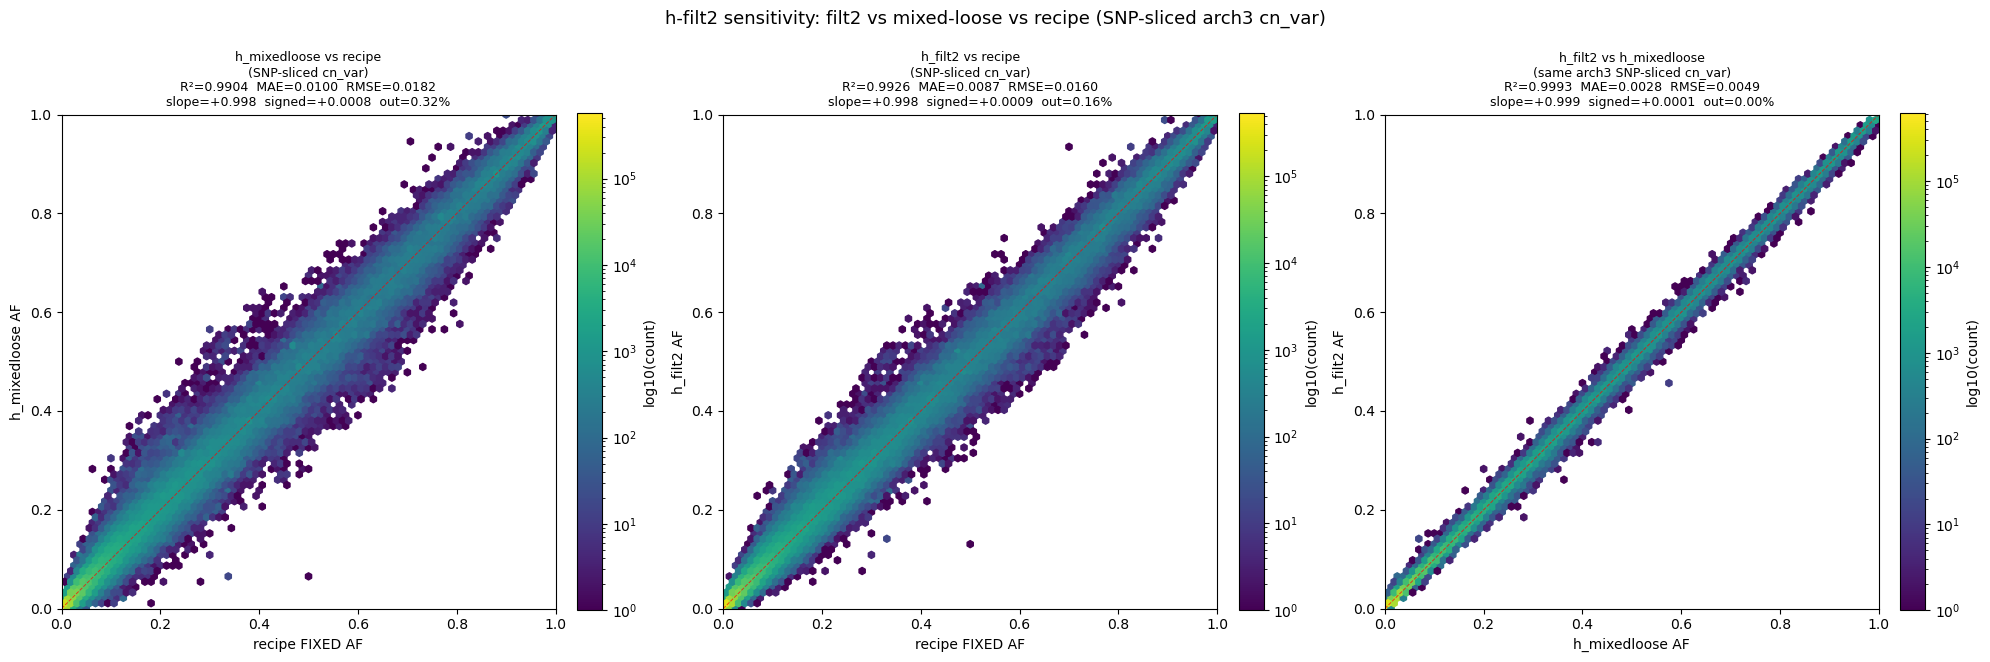

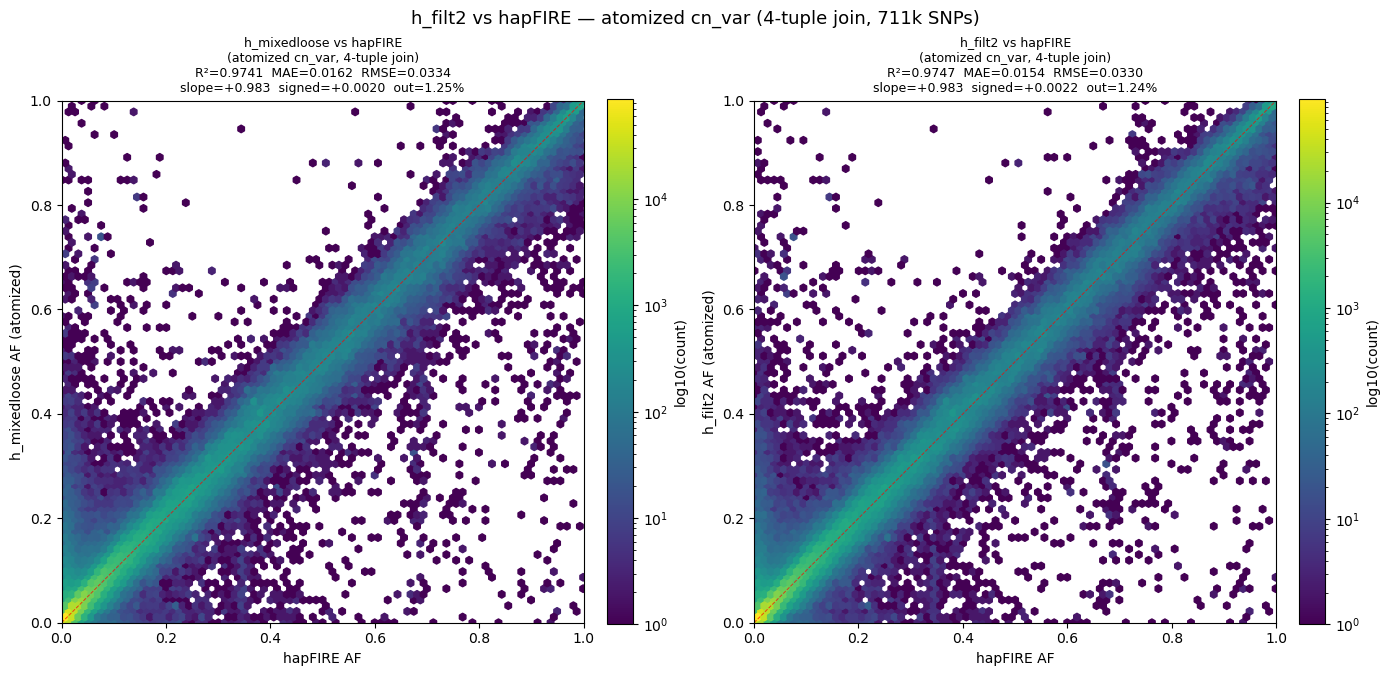

In [53]:
# === h-filt2: project through SNP-sliced cn_var (recipe comparison) ===
H_FILT2 = ROOT / 'scratch' / 'v3qc_v3_filt2_chr1' / 'SEEDMIX_S1.h_per_chrom.npz'
H_ML    = ROOT / 'scratch' / 'v3qc_v3_mixedloose_chr1' / 'SEEDMIX_S1.h_per_chrom.npz'

h_filt2, fnd_filt2 = load_h(H_FILT2)
h_ml2,   fnd_ml2   = load_h(H_ML)

import json as _json2
with open(ROOT / 'data/founder_split_cactus_pg.json') as _f:
    _spl2 = _json2.load(_f)
_c2 = np.array([str(s) in set(map(str, _spl2['cactus'])) for s in fnd_filt2])

print('=== h-vector stats ===')
for lbl, hv in [('mixedloose', h_ml2), ('filt2', h_filt2)]:
    F_ = len(hv)
    ratio = hv[_c2].mean() / hv[~_c2].mean()
    print(f'  {lbl:<12}  CV={hv.std()/hv.mean():.4f}  cactus/PG per-founder ratio={ratio:.4f}  '
          f'cactus_sum={hv[_c2].sum():.4f} (unif={_c2.sum()/F_:.4f})')

# h-vector correlation
r_hh = np.corrcoef(h_ml2, h_filt2)[0,1]
print(f'\nh_mixedloose vs h_filt2: Pearson r = {r_hh:.6f}  max|Δ|={np.abs(h_ml2 - h_filt2).max():.4e}')

# Project through SNP-sliced cn_var (cv_chr1/cvc_chr1 from cell 2)
af_filt2_snp = project_snp(h_filt2)
af_ml2_snp   = project_snp(h_ml2)

print('\n=== Metrics vs recipe (SNP-sliced cn_var) ===')
for lbl, af_ in [('h_mixedloose', af_ml2_snp), ('h_filt2', af_filt2_snp)]:
    m = metrics(recipe_fixed, af_, None)
    if m:
        print(f'  {lbl:<14}  n={m["n"]:>8,}  R²={m["r2"]:.4f}  MAE={m["mae"]:.4f}  RMSE={m["rmse"]:.4f}  bias={m["signed"]:+.4f}  out={100*m["out"]:.2f}%')

print('\n=== Metrics vs hapFIRE (SNP-sliced cn_var, single-ALT mask) ===')
for lbl, af_ in [('h_mixedloose', af_ml2_snp), ('h_filt2', af_filt2_snp)]:
    m = metrics(hf_af, af_, single_alt_mask)
    if m:
        print(f'  {lbl:<14}  n={m["n"]:>8,}  R²={m["r2"]:.4f}  MAE={m["mae"]:.4f}  RMSE={m["rmse"]:.4f}  bias={m["signed"]:+.4f}  out={100*m["out"]:.2f}%')

# === hapFIRE comparison via atomized cn_var 4-tuple join (pre-computed by F1 job) ===
print('\n=== hapFIRE comparison via atomized cn_var (F1 job output) ===')
f1 = pd.read_csv(ARCH / 'SEEDMIX_S1_chr1_filt2_vs_mixedloose_vs_hapfire.tsv', sep='\t')
print(f'  4-tuple records: {len(f1):,}')
for lbl, col in [('h_mixedloose', 'af_old'), ('h_filt2', 'af_filt2')]:
    d_ = f1[col] - f1['af_hapfire']
    mae_ = np.abs(d_).mean(); rmse_ = np.sqrt((d_**2).mean())
    bias_ = d_.mean(); n10 = (np.abs(d_) > 0.10).sum()
    print(f'  {lbl:<14}  MAE={mae_:.4f}  RMSE={rmse_:.4f}  bias={bias_:+.4f}  |Δ|>0.10:{n10:,} ({100*n10/len(f1):.2f}%)')

# Outlier transitions mixedloose → filt2 (atomized 4-tuple)
old_outl   = np.abs(f1['af_old']   - f1['af_hapfire']) > 0.10
filt2_outl = np.abs(f1['af_filt2'] - f1['af_hapfire']) > 0.10
print(f'\n  Outlier transitions (mixedloose → filt2):')
print(f'    fixed by filt2:       {(old_outl & ~filt2_outl).sum():,}  ({100*(old_outl & ~filt2_outl).sum()/old_outl.sum():.1f}% of old outliers)')
print(f'    introduced by filt2:  {(~old_outl & filt2_outl).sum():,}')
print(f'    still outlier:        {(old_outl & filt2_outl).sum():,}')

# === Scatter: 3-panel mixedloose vs recipe / filt2 vs recipe / filt2 vs mixedloose ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
hexbin(axes[0], recipe_fixed, af_ml2_snp,   'recipe FIXED AF', 'h_mixedloose AF',
       'h_mixedloose vs recipe\n(SNP-sliced cn_var)')
hexbin(axes[1], recipe_fixed, af_filt2_snp,  'recipe FIXED AF', 'h_filt2 AF',
       'h_filt2 vs recipe\n(SNP-sliced cn_var)')
hexbin(axes[2], af_ml2_snp,   af_filt2_snp,  'h_mixedloose AF', 'h_filt2 AF',
       'h_filt2 vs h_mixedloose\n(same arch3 SNP-sliced cn_var)')
plt.suptitle('h-filt2 sensitivity: filt2 vs mixed-loose vs recipe (SNP-sliced arch3 cn_var)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_h_filt2_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

# === Scatter: filt2 and mixedloose vs hapFIRE (atomized 4-tuple) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
hexbin(axes[0], f1['af_hapfire'], f1['af_old'],
       'hapFIRE AF', 'h_mixedloose AF (atomized)',
       'h_mixedloose vs hapFIRE\n(atomized cn_var, 4-tuple join)')
hexbin(axes[1], f1['af_hapfire'], f1['af_filt2'],
       'hapFIRE AF', 'h_filt2 AF (atomized)',
       'h_filt2 vs hapFIRE\n(atomized cn_var, 4-tuple join)')
plt.suptitle('h_filt2 vs hapFIRE — atomized cn_var (4-tuple join, 711k SNPs)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_arch3_h_filt2_vs_hapfire.png', dpi=130, bbox_inches='tight')
plt.show()
